Heavenly Father,

In a time when we use knowledge and technology to understand and make decisions that affect people and the whole of your creation, we ask for Your guidance on matters of fairness and justice.

Lord, we know that You see every person and creature as valuable, as displays of your glory, and we ask for this same lens of love as we work with data.

Guard us, Father, against the subtle biases that can arise, even when we have the best intentions. May we never let variables like gender, age, or circumstance become walls that divide us. Teach us to recognize when seemingly neutral choices become harmful proxies for deeper inequalities, and give us the humility and courage to correct our course when we fall short.

Show us the ways to refine our efforts through new and improved methods, and let these models reflect not the imperfections of this world, but your kingdom, and the grace You have shown us.

Let all our work be pleasing to You.

In Jesus' name, we pray. Amen.

![](https://images.unsplash.com/photo-1545044846-351ba102b6d5?q=80&w=1974&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D)

# Dataset: Melbourne housing prices

[Our dataset](https://www.kaggle.com/datasets/madhumithakolkar/l1-and-l2-regularization?resource=download) contains information about housing in Melbourne and has 34,857 rows and 21 columns. Here are the key details about the columns:

1. **Suburb**: Name of the suburb (string).
2. **Address**: Address of the property (string).
3. **Rooms**: Number of rooms in the property (integer).
4. **Type**: Type of property (string).
5. **Price**: Sale price (float), with some missing values.
6. **Method**: Sale method (string).
7. **SellerG**: Name of the seller (string).
8. **Date**: Date of sale (string).
9. **Distance**: Distance to the Central Business District (float).
10. **Postcode**: Postal code of the property (float).
11. **Bedroom2**: Number of bedrooms (float), with missing values.
12. **Bathroom**: Number of bathrooms (float), with missing values.
13. **Car**: Number of car spaces (float), with missing values.
14. **Landsize**: Size of the land (float), with missing values.
15. **BuildingArea**: Size of the building (float), with significant missing values.
16. **YearBuilt**: Year the building was built (float), with many missing values.
17. **CouncilArea**: Name of the local government area (string).
18. **Lattitude**: Latitude of the property (float), with missing values.
19. **Longtitude**: Longitude of the property (float), with missing values.
20. **Regionname**: Region of the property (string).
21. **Propertycount**: Number of properties in the suburb (float).

In [ ]:
import pandas as pd

housing = pd.read_csv('https://cs.calvin.edu/courses/data/202/fsantos/datasets/melbourne_housing.csv')
housing.head()

Let's drop the rows with no values for Price (as it is critical for analysis):

In [ ]:
housing = housing.dropna(subset=['Price'])
housing.head()

Now, we will try to do linear regression for prediciting `Price`. We will also use Imputers to deal with missing values!

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer

# Define feature columns and the target variable
X = housing.drop(columns=['Price', 'Address', 'Date'])  # Exclude irrelevant columns
y = housing['Price']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Numerical features will be scaled and missing values imputed with the median
numerical_features = ['Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount']
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Categorical features will be one-hot encoded
categorical_features = ['Suburb', 'Type', 'Method', 'SellerG', 'CouncilArea', 'Regionname']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both numerical and categorical transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create a pipeline with preprocessor and linear regression
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the pipeline
pipeline.fit(X_train, y_train)

# Make predictions
y_pred = pipeline.predict(X_test)

# Evaluate the model using RMSE
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print(f"Root Mean Squared Error (RMSE): {rmse}")

Is this acceptable? One way to checking is to use EAR (Error-to-Average Ratio):
$$
   \text{EAR} = \frac{\text{RMSE}}{\text{mean of actual values}}
$$


In [ ]:
print(f"Error-to-Average Ratio (EAR): {rmse / y_test.mean()}")

What does this value mean?

# Bias and Variance

- Is it sufficient to have a good accuracy with the testing dataset?

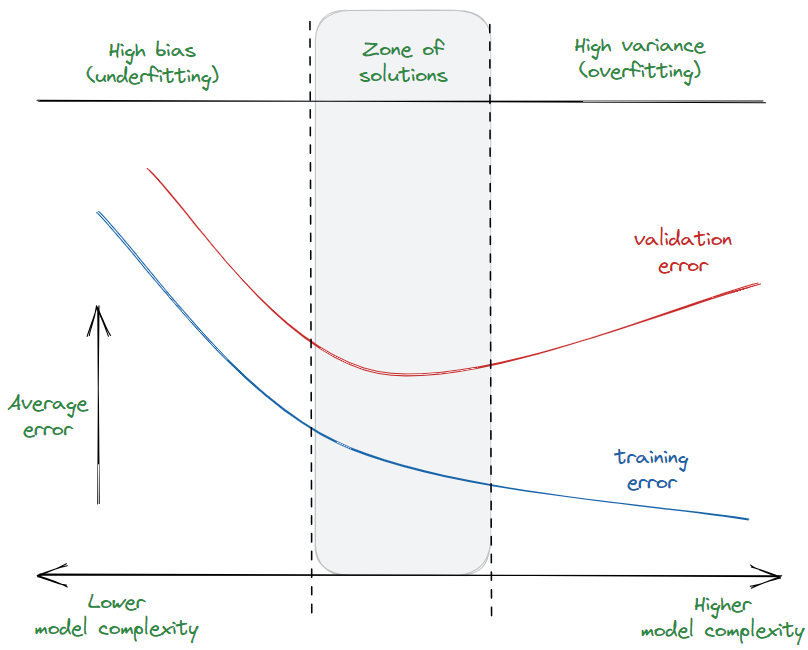

*Bias and variance* are **two key sources of error** that affect the performance of predictive models.
- **Bias** refers to the error introduced by the **model's assumptions**. High bias indicates that the model is too simplistic and makes strong assumptions about the data, which can lead to underfitting.
  - **Underfitting** happens when a model is unable to capture the underlying patterns in the data.
- **Variance** refers to the model's **sensitivity to fluctuations in the training data**. High variance means that the model is too complex and captures noise or random fluctuations in the data, which can lead to overfitting.
  - **Overfitting** occurs when a model performs well on training data but poorly on unseen data because it has learned patterns specific to the training data rather than general patterns.

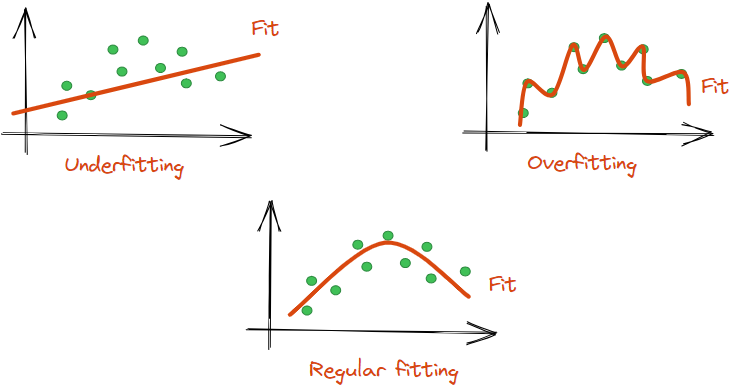

| Error         | Situation    | Causes                                            |                             |
|---------------|--------------|---------------------------------------------------|-----------------------------|
| High bias     | Underfitting | Model is too simple (doesn't capture information) | Too few and/or bad features |
| High variance | Overfitting  | Model is too complex (captures "noise")           | Too much features           |

- Usually this is a **tradeoff** when considering the choice of models...

## Questions:

1. What will be the effect in bias/variance if we don't have sufficient data?
2. What will be the effect in bias/variance if our data are "noisy"? (i.e., imprecisions, errors, etc).
3. What will be the effect in bias/variance if we don't have balanced data? (i.e., more cases for one class than for another)

# Cross-Validation

Cross-validation provides a more reliable estimate of the model's performance by ensuring it is not evaluated on a single training or testing set. Instead, it evaluates the model's ability to generalize across multiple splits, reducing bias in performance evaluation.

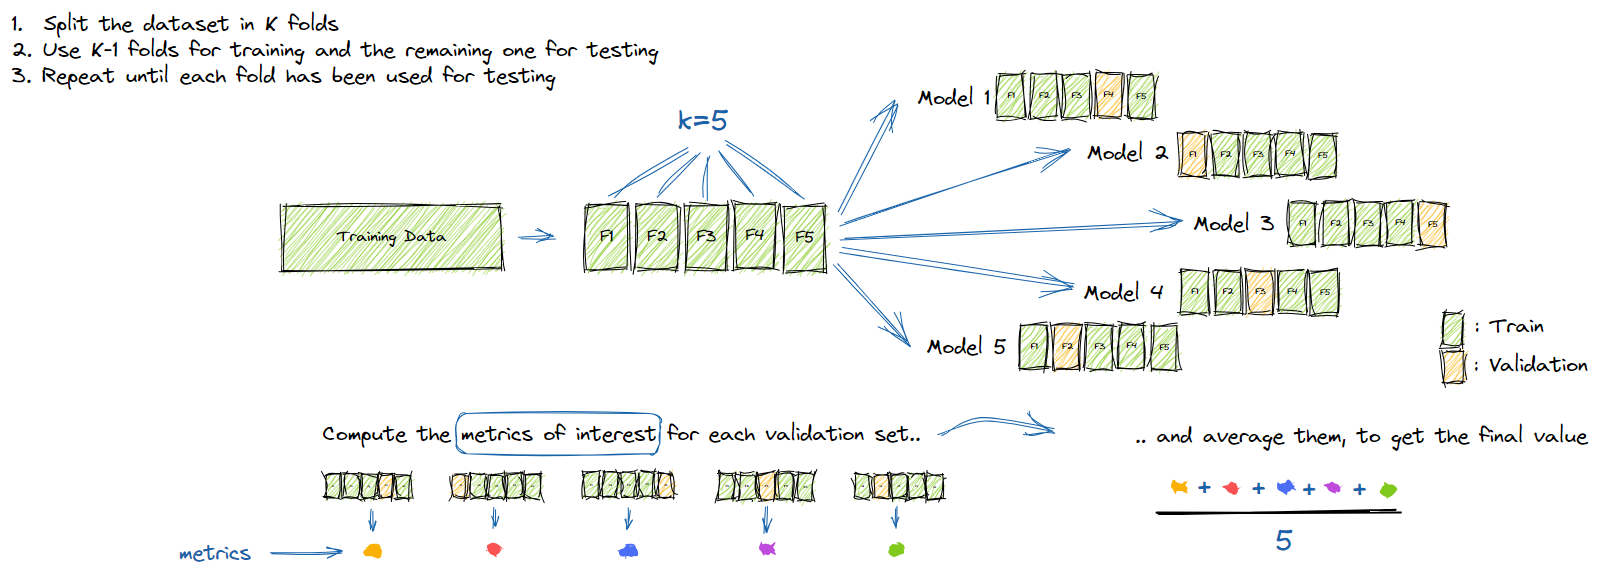

**Advantages**:
   - Every data point is used for both training and testing, which provides a more robust estimate of model performance.
   - Reduces variability in performance metrics compared to a single train-test split.

**Disadvantages**:
   - Computationally expensive since the model is trained \(k\) times.

## Let's try it!

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

# Define the number of folds for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Use cross_val_score to get RMSE on each fold of the training data
rmse_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='neg_root_mean_squared_error')

rmse_scores, np.mean(rmse_scores), np.var(rmse_scores)  # Output RMSE scores and variance across folds

Is this good? What should we be looking here?

# Regularization

Regularization means the **techniques used to prevent overfitting** by **adding a penalty to the model's complexity**.

In the context of linear models, the two most common forms of regularization are:

### 1. **L1 Regularization (Lasso)**
- **L**east **A**bsolute **S**hrinkage and **S**election **O**perator
- Adds the absolute value of the coefficients as a penalty to the loss function:
  
  $$
  \text{Loss} = \text{MSE} + \lambda \sum_{i=1}^n |w_i|
  $$
  where $\lambda$ is a regularization parameter controlling the strength of regularization, $w_i$ are the weights, and MSE is the Mean Squared Error.

- Remember: since we want to minimize the loss function...
  - It tends to drive some of the coefficients to zero, effectively selecting only the most important features.
  - This is reffered as **sparsity** - only a subset of the features has non-zero weights, meaning that only a limited number of features contribute to the model’s predictions, while the rest are excluded.

#### Advantages:
- **Feature Selection:** Because L1 regularization forces some coefficients to zero, it inherently performs feature selection. The features with non-zero coefficients are considered important, while the ones with zero coefficients are effectively removed from the model.
- **Interpretability:** Sparsity helps create more interpretable models, as the final model depends on fewer features, making it easier to understand which features have the most significant influence on the predictions.
- **Dimensionality Reduction:** By setting many coefficients to zero, Lasso regression can reduce the dimensionality of the problem, making it a useful tool when dealing with high-dimensional datasets where many features may be irrelevant or redundant.

## Let's try it

In [ ]:
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=50, max_iter=100, tol=0.1))
])

# Train the Lasso pipeline
lasso_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_lasso = lasso_pipeline.predict(X_test)

# Calculate RMSE for Lasso
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = mse_lasso ** 0.5

# Calculate Error-to-Average Ratio (EAR) for Lasso
print(f"Error-to-Average Ratio (EAR): {rmse_lasso / y_test.mean()}")

### 2. **L2 Regularization (Ridge)**
- Adds the square of the magnitude of the coefficients as a penalty to the loss function.

  $$
  \text{Loss} = \text{MSE} + \lambda \sum_{i=1}^n w_i^2
  $$

- Shrinks the coefficients but does not force them to be zero, meaning it retains all features but reduces their impact.
- Thus, it does not perform feature selection, however, it is **useful when features have multicollinearity** (i.e., two features are highly correlated)
  - When two or more features are correlated, we usually get a **"ridge** in the parameter space:

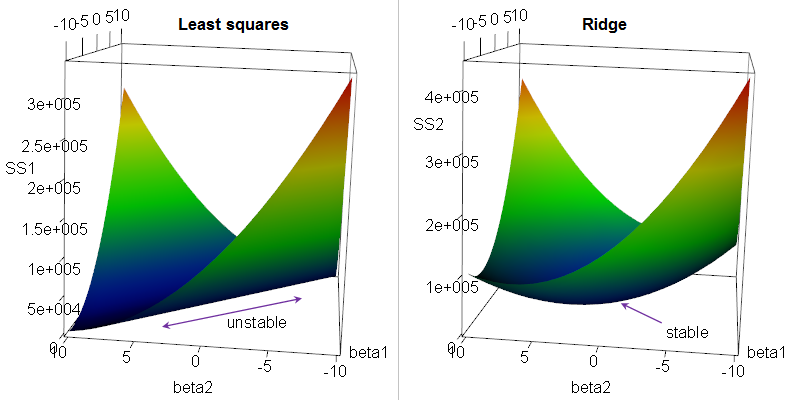

- Thus, Ridge Regression "fixes" the ridge - it adds a penalty that turns the ridge into a nice peak in likelihood space, equivalently a nice depression in the criterion we're minimizing

In [ ]:
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=10, max_iter=1000, tol=0.3))
])

# Train the Ridge pipeline
ridge_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_ridge = ridge_pipeline.predict(X_test)

# Calculate RMSE for Ridge
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = mse_ridge ** 0.5

# Calculate Error-to-Average Ratio (EAR) for Ridge
print(f"Error-to-Average Ratio (EAR): {rmse_ridge / y_test.mean()}")

### 3. Elastic Net
Elastic Net combines both L1 and L2 regularization, allowing for feature selection (like L1) while also maintaining the advantages of L2. The regularization term is a weighted sum of both L1 and L2 penalties.

  $$
  \text{Loss} = \text{MSE} + \lambda_1 \sum_{i=1}^n |w_i| + \lambda \sum_{i=1}^n w_i^2
  $$

- This is usually achieved with the setting of a hyperparameter called $\alpha$.
  - **$\alpha = 0$**: The model becomes Ridge regression (pure L2 regularization).
  - **$\alpha = 1$**: The model becomes Lasso regression (pure L1 regularization).
  - **$\alpha \in (0, 1)$**: The model is a combination of Lasso and Ridge, mixing both L1 and L2 penalties.

In [ ]:
from sklearn.linear_model import ElasticNet

# Create a pipeline with Elastic Net (combined L1 and L2 regularization)
elastic_net_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(alpha=10, l1_ratio=0.5, max_iter=1000))  # Default alpha, l1_ratio = 0.5 (balance between L1 and L2)
])

# Train the Elastic Net pipeline
elastic_net_pipeline.fit(X_train, y_train)

# Make predictions using the Elastic Net model
y_pred_elastic_net = elastic_net_pipeline.predict(X_test)

# Calculate RMSE for Elastic Net
mse_elastic_net = mean_squared_error(y_test, y_pred_elastic_net)
rmse_elastic_net = mse_elastic_net ** 0.5

print(f"Error-to-Average Ratio (EAR): {rmse_elastic_net / y_test.mean()}")

# Hyperparameter Tuning

- How do we choose values for $\lambda$, $\alpha$, or even $k$ in kNN? (i.e., hyperparameters).

## 1. Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet

# Define the parameter grid for Elastic Net
param_grid = {
    'regressor__alpha': [0.1, 1.0, 10.0],  # Regularization strength
    'regressor__l1_ratio': [0.1, 0.5, 0.9]  # Balance between L1 and L2 regularization
}

# Create a pipeline with Elastic Net
elastic_net_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(max_iter=1000))
])

# Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(elastic_net_pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the model with grid search
grid_search.fit(X_train, y_train)

# Retrieve the best parameters and the best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Make predictions using the best model
y_pred_best = best_model.predict(X_test)

# Calculate RMSE for the best model
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = mse_best ** 0.5

# Calculate Error-to-Average Ratio (EAR) for the best model
ear_best = rmse_best / y_test.mean()

print(f"Best Parameters: {best_params}")
print(f"Best RMSE: {rmse_best}")
print(f"Best EAR: {ear_best}")

## 2. Random search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Define a larger parameter distribution for Elastic Net
param_distributions = {
    'regressor__alpha': np.logspace(-3, 3, 50),  # Search alpha from 0.001 to 1000 in log scale
    'regressor__l1_ratio': np.linspace(0.1, 0.9, 20)  # Search l1_ratio between 0.1 and 0.9
}

# Create a pipeline with Elastic Net
elastic_net_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(max_iter=1000))
])

# Initialize RandomizedSearchCV with 5-fold cross-validation
random_search = RandomizedSearchCV(elastic_net_pipeline, param_distributions, cv=2,
                                   scoring='neg_mean_squared_error', n_iter=10, random_state=42, n_jobs=-1)

# Fit the model with random search
random_search.fit(X_train, y_train)

# Retrieve the best parameters and the best model
best_params_random = random_search.best_params_
best_model_random = random_search.best_estimator_

# Make predictions using the best model
y_pred_best_random = best_model_random.predict(X_test)

# Calculate RMSE for the best model
mse_best_random = mean_squared_error(y_test, y_pred_best_random)
rmse_best_random = mse_best_random ** 0.5

# Calculate Error-to-Average Ratio (EAR) for the best model
ear_best = rmse_best / y_test.mean()

print(f"Best Parameters: {best_params}")
print(f"Best RMSE: {rmse_best}")
print(f"Best EAR: {ear_best}")

## 3. Bayesian search

Bayesian Search strategically chooses the next set of hyperparameters to evaluate based on the performance of previous trials. This makes the search more efficient and smarter, particularly for high-dimensional or expensive-to-evaluate models.

We will need to use another library called `scikit-optimize` (another alternative is Optuna).

In [ ]:
!pip install scikit-optimize

In [ ]:
from skopt import BayesSearchCV
from sklearn.linear_model import ElasticNet

# Define the parameter search space
search_space = {
    'regressor__alpha': (1e-3, 1e3, 'log-uniform'),  # Log-uniform sampling for alpha between 0.001 and 1000
    'regressor__l1_ratio': (0, 1.0)  # Linear sampling for l1_ratio between 0 and 1
}

# Set up Bayesian optimization with cross-validation
bayes_search = BayesSearchCV(
    elastic_net_pipeline,  # Use the full pipeline
    search_spaces=search_space,
    n_iter=10,  # Number of parameter settings to sample
    cv=2,  # 5-fold cross-validation
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # Use all available cores
    random_state=42
)

# Fit the Bayesian search
bayes_search.fit(X_train, y_train)

# Get the best parameters and score
print("Best parameters:", bayes_search.best_params_)
print("Best score:", -bayes_search.best_score_)

# Make predictions using the best found model
y_pred_best = bayes_search.best_estimator_.predict(X_test)

# Calculate the RMSE and EAR
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = mse_best ** 0.5
ear_best = rmse_best / y_test.mean()

print(f"Best Parameters: {best_params}")
print(f"Best RMSE: {rmse_best}")
print(f"Best EAR: {ear_best}")

# Occam's razor and the problem of circular validation

> "All models are wrong; but some are useful." (George E. P. Box)

- In science and statistics, the principle of **Occam’s Razor** suggests that simpler models, which explain the data adequately without unnecessary complexity, should be preferred. Complex models that incorporate too many variables or interactions may capture differences that don’t matter (i.e., overfitting), while simpler models focus on the most important differences.
- However, **distinguishing between relevant and irrelevant complexities is not always straightforward**. Deciding which variables, interactions, or patterns are essential to include in the model—and which can be safely ignored—can be deeply challenging.
  - Thus, we are always at the risk of falling into a circular argument similar to [the experimenter's regress](https://en.wikipedia.org/wiki/Experimenter%27s_regress):
    - "How do you know that this model is correctly fitted (neither over nor underfitted)? Because it adjusts well to the data". But then:
    - But how do you know that the model adjusts well to the data? Because it is neither over nor under-fitted."

- Thus, **what counts as 'sufficient' or 'adequate' depends not only on statistical criteria but also on subjective judgment, theoretical context, and domain knowledge**.
  - In other words, [data and models alone are not sufficient](https://royalsocietypublishing.org/doi/full/10.1098/rsta.2018.0145).

- Authors sometimes even point to the influence of **social values** in choosing of what counts.
  - For example, in models of economic development, the decision to prioritize certain indicators (e.g., GDP growth vs. quality of life or environmental sustainability) reflects not just empirical evidence but also the values of the institutions funding the research.
  - This is affected by political arrangements and authorities: how does the distribution of expert authority influence decisions about what is important in models? Should non-expert knowledge play a role in determining which factors matter, particularly in areas that affect public life?